# DEF-D Fysieke Ontwerpopdracht 2 invul template

## Groep informatie

Aan het einde van deze ontwerpopdracht lever je als groep één gezamenlijk notebook in (als in *PR* op GitHub en de link op Brightspace). Zet jullie groepsnummer, studienummers en namen in onderstaande tabel zodat wij zeker weten dat het groepsvormen goed is gegaan.

| Groep: 20     |  |
| :-------------|:-------------|
| Abenezer Bayu| 6268315 |
| Ben Geertman | 6529100 |
| Tahlia van den Berg| 6399991 |
| Planning Groep: 20     |Tijdstip / Tijdspanne  |
|---|---|
| Condensator af | 12:30 |
| Sensor af | 16:00 |
| Sensor testen | 17:00 |
| Opgeruimd | 17:30 |
| groep aanwezig 1| 10:45 |
| groep aanwezig 2| Tijdspanne |
| Pauze 1| 12:30 / 13:30 |
| Pauze 2| 15:15 / 15:45 |

## *Opdracht 1*: Sanity check 3

#### Voeg hier een foto van de schets van je plaatcondensator in. Geef daarbij ook duidelijk de waarde van $A$ en $d$ aan.
<img src="schetscondensator.jpeg" alt="schets student 1" width="400"/>

In [1]:
# Schrijf hier een python functie die de capaciteit van een plaatcondensator uitrekent. Zorg dat de functie
# als input de ontwerpparameters van de vlakke plaat formule accepteert (oppervlakte, afstand en diëlektrische
# constante) en als output de capaciteit van de vlakke plaat condensator met die ontwerpparameters.
# Je gaat deze formule de rest van de dag gebruiken: controleer hem goed!

epsilon0 = 8.854e-12  # permittiviteit van vacuum (F/m)

def vlakkeplaat(l, b, d, epsilonr):
    C = epsilon0 * epsilonr * l * b / d
    return C #in Ah

# Optioneel: schrijf je functie zodanig dat je arrays als input kan geven en (dus) ook arrays als output.

In [2]:
# Gebruik je formule om uit te rekenen wat je verwacht dat de capaciteit van jullie vlakke plaat condensatoren
# gaat zijn.

l = 0.1  # lengte in meters
b = 0.1  # breedte in meters
d = 0.004  # afstand in meters
epsilonr = 1  # diëlektrische constante (karton)

C = vlakkeplaat(l, b, d, epsilonr)


print(f"Berekende capaciteit plaatcondensator groep 20 is {C*1e12:.1f} pF")



Berekende capaciteit plaatcondensator groep 20 is 22.1 pF


#### Voeg hier een foto van je plaatcondensator en van de meting op de scope in. Dus 2 foto's.
![scope meting 1](condensator.jpeg)
![scope meting 2](Oscilloscoop.jpeg)

### Meting capaciteit
Vul onderstaande tabel in. Bij Sanity check 2 heb je afgeleid hoe je van berekende capaciteit naar berekend voltage gaat en terug. 


| Namen         | Berekende capaciteit   | Berekend Voltage | Gemeten Voltage | Gemeten capaciteit   |
|-------------|-------------:|-------------:|-------------:|-------------:|
| groep 20 |  {C*1e12:.1f} pF | 390 mV | 73 | 360mV |

## *Opdracht 2:* Synthese.

#### Voeg hier voor een foto van je schets(en) van minimaal drie sensoren in.
![drie schetsen](schetsenopstelling.jpeg)


## Opdracht 3: Welke sensor gaan jullie maken?

Pas deze tekst aan: Wij gaan een sensor maken die gewicht meet.

## Opdracht 4: Uitgewerkte schets (afmetingen!) en plot van de ontwerpgrafiek.

#### Voeg hier een foto van jullie uitgewerkte  schets van de sensor die jullie gaan maken in
![uitgewerkte schets](uitgebreideschetsopstelling.jpeg)

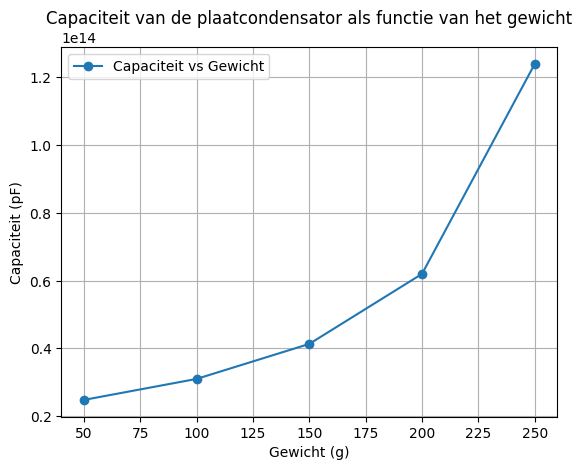

In [3]:
# Plot hier de verwachte ontwerpgrafiek van jullie sensoren.
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit

gewichten = np.array([50, 100, 150, 200, 250]) # in gram

afstanden = 1.5 - 0.005 * gewichten
l = 25
b = 14
epsilonr = 1

capaciteiten = vlakkeplaat(l/100, b/100, afstanden/100, epsilonr) * 1e12 * np.ones_like(gewichten)  # in pF
plt.figure()
plt.plot(gewichten, capaciteiten*1e12, 'o-', label='Capaciteit vs Gewicht')
plt.xlabel('Gewicht (g)')
plt.ylabel('Capaciteit (pF)')
plt.title('Capaciteit van de plaatcondensator als functie van het gewicht')
plt.grid(); plt.legend()
plt.show()


## Opdracht 5: Invullen tabel LTSpice.

|         | Capaciteit waarde (pF)  | LTSpice berekend output Vpp (mV)|
|-------------|-------------:|-------------:|
| minmale capaciteit| 30 | 200 |
| gemiddelde capaciteit| 100 | 1000 |
| maximale capaciteit| 160 | 1600 |

## Opdracht 6: Foto's werkende opstelling.

#### Voeg hier de foto's van je sensoren in actie in.
![meting 1](meting1.jpeg)
![meting 2](meting2.jpg)

## Opdracht 7: Plot de kalibratiegrafiek.

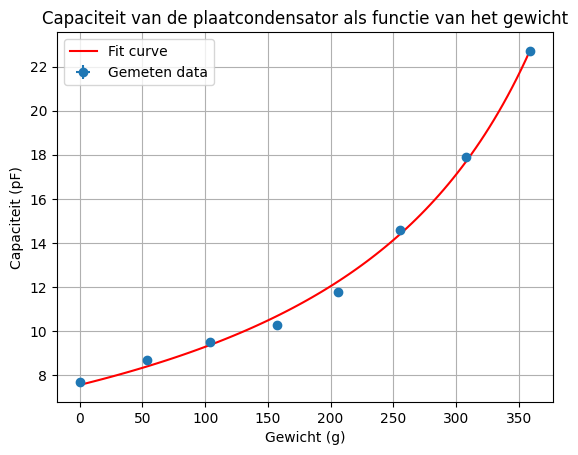

Fit resultaten: epsilonr = 0.0263 ± 0.0007


In [4]:
# Plot hier je gemeten kalibratiegrafiek en plot in dezelfde figuur ook je verwachte ontwerpgrafiek.
def fitfunc(gewicht, eps, gewicht0):
    return epsilon0 * eps * l * b /(8 - 1 * (gewicht + gewicht0)/50) * 1e12

gewichten_meting = np.array([0, 53.5, 104.1, 157.1, 206.1, 255.5, 307.8, 359.2]) # in gram
capaciteiten_meting = np.array([7.7, 8.7, 9.5, 10.3, 11.8, 14.6, 17.9, 22.7]) # in pF

u_gewichten = 0.1
u_capaciteit = 0.1


popt, pcov = curve_fit(fitfunc, gewichten_meting, capaciteiten_meting, p0=[2, 0])

xfit = np.linspace(gewichten_meting.min(), gewichten_meting.max(), 100)
yfit = fitfunc(xfit, *popt)
plt.figure()
plt.errorbar(gewichten_meting, capaciteiten_meting, xerr=u_gewichten, yerr=u_capaciteit, fmt='o', label='Gemeten data')
plt.plot(xfit, yfit, 'r-', label='Fit curve')
plt.xlabel('Gewicht (g)')
plt.ylabel('Capaciteit (pF)')
plt.title('Capaciteit van de plaatcondensator als functie van het gewicht')
plt.grid(); plt.legend()
plt.show()

eps_fit = popt[0]
u_eps_fit = np.sqrt(pcov[0, 0])
print(f"Fit resultaten: epsilonr = {eps_fit:.4f} ± {u_eps_fit:.4f}")

## Opdracht 8: Vul de tekst aan.

Onze sensor kan nog verbetered worden door de volgende verbeteringen (minimaal 2):

* stabieliteit van de constructie verbeteren
* de platen kunnen beter parallel en recht gehouden worden
* de veren moeten minder weerstand hebben

## Opdracht 9: Uiteindelijke ontwerp en kalibratiegrafiek.

#### Voeg hier een foto van je uiteindelijke sensor in.
![foto sensor](meting1.jpeg)

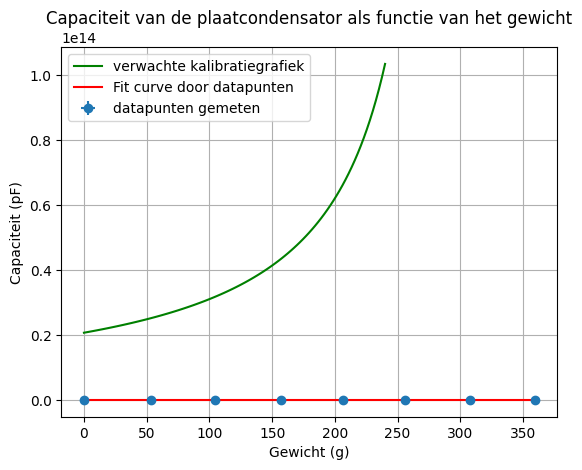

In [5]:
# Plot hier je oorspronkelijke en je uiteindelijke kalibratiegrafieken, fit daar een bijpassende lijn door
# en zet ook de verwachte ontwerpgrafiek erbij

# Door vele struggles met arduino's en andere apparaten hebben we geen tijd gehad om echt een tweede kalibratie te maken. Maar het design is wel erg veel ontwikkeld door het process heen

gewichten_linspace = np.linspace(0, 240, 100) # in gram

afstanden = 1.5 - 0.005 * gewichten_linspace
l = 25
b = 14
epsilonr = 1

capaciteiten = vlakkeplaat(l/100, b/100, afstanden/100, epsilonr) * 1e12 * np.ones_like(gewichten_linspace)  # in pF
plt.figure()
plt.plot(gewichten_linspace, capaciteiten*1e12, 'g-', label='verwachte kalibratiegrafiek')
plt.errorbar(gewichten_meting, capaciteiten_meting, xerr=u_gewichten, yerr=u_capaciteit, fmt='o', label='datapunten gemeten')
plt.plot(xfit, yfit, 'r-', label='Fit curve door datapunten')
plt.xlabel('Gewicht (g)')
plt.ylabel('Capaciteit (pF)')
plt.title('Capaciteit van de plaatcondensator als functie van het gewicht')
plt.grid(); plt.legend()
plt.show()

# Zoals in de grafiek te zien is, kloppen de metingen helemaal niet met de kalibratie grafiek... Dit komt omdat de gemeten epsilonr veel lager is dan de verwachte epsilonr.
# Dit komt waarschijnlijk doordat er lucht tussen de platen zit, en dat de afstand tussen de platen groter is dan verwacht. De metingen zijn dus niet heel betrouwbaar, maar het design is wel erg veel verbeterd door het proces heen.

## Opdracht 10: Vul hieronder de conclusie in.

Uiteindelijk is het redelijk gelukt om een werkende gewichtssensor te maken. De sensor kan qua accuraatheid een stuk beter en stabieler gemaakt worden. De onzekerheden van de gemeten waardes zijn echter erg klein, dus dat is goed.

Het verband tussen het gewicht en de capaciteit volgt het verwachte verband goed, maar op een manier met waarden die echt onzin zijn. De epsilonr is bijvoorbeeld is bijvoorbeeld veel te laag, 0.026, terwijl deze voor lucht ongeveer 1 zou moeten zijn. Bovendien is er een corrigeer factor nodig voor het gewicht, die momenteel gefit wordt als -137... Een negatief gewicht voor de opstelling zonder gewichten is natuurlijk onzin. De reden dat deze corrigeer factor nodig is, is waarschijnlijk dat de afstand tussen de platen niet goed bepaald kan worden, en dat er ook nog andere factoren meespelen zoals de veren en de constructie van de sensor.

Een aantal oorzaken voor de slechte waardes is dat we geen mooie platte platen gebruikte, en dat de beginafstand niet goed te meten was. De veren die gebruikt werden waren ook erg stroef, waardoor het gewicht niet altijd de volledige kracht uitoefende op de platen.

## Opdracht 11: Kopieer hieronder de leerdoelen.
1. Het kunnen gebruiken van de eigenschappen van een elektrische component in een ontwerpproces om een fysische grootheid te meten.
2. Kennis hebben van gedrag van elektrische componenten en meetopstellingen.
3. Onderdelen van een datasheet zoals een kalibratiegrafiek opstellen, gevoeligheid en onzekerheid beschrijven.

kopieer hier de cel(len) waaruit blijkt dat jullie leerdoel 1 beheersen.

## *Opdracht 2:* Synthese.

#### Voeg hier voor een foto van je schets(en) van minimaal drie sensoren in.
![drie schetsen](schetsenopstelling.jpeg)


## Opdracht 6: Foto's werkende opstelling.

#### Voeg hier de foto's van je sensoren in actie in.
![meting 1](meting1.jpeg)
![meting 2](meting2.jpg)

## Opdracht 4: Uitgewerkte schets (afmetingen!) en plot van de ontwerpgrafiek.

#### Voeg hier een foto van jullie uitgewerkte  schets van de sensor die jullie gaan maken in
![uitgewerkte schets](uitgebreideschetsopstelling.jpeg)

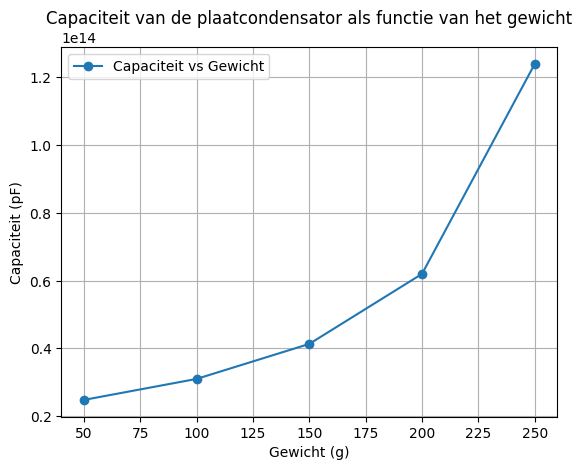

In [6]:
# Plot hier de verwachte ontwerpgrafiek van jullie sensoren.
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit

gewichten = np.array([50, 100, 150, 200, 250]) # in gram

afstanden = 1.5 - 0.005 * gewichten
l = 25
b = 14
epsilonr = 1

capaciteiten = vlakkeplaat(l/100, b/100, afstanden/100, epsilonr) * 1e12 * np.ones_like(gewichten)  # in pF
plt.figure()
plt.plot(gewichten, capaciteiten*1e12, 'o-', label='Capaciteit vs Gewicht')
plt.xlabel('Gewicht (g)')
plt.ylabel('Capaciteit (pF)')
plt.title('Capaciteit van de plaatcondensator als functie van het gewicht')
plt.grid(); plt.legend()
plt.show()


kopieer hier de cel(len) waaruit blijkt dat jullie leerdoel 2 beheersen.

## Opdracht 5: Invullen tabel LTSpice.

|         | Capaciteit waarde (pF)  | LTSpice berekend output Vpp (mV)|
|-------------|-------------:|-------------:|
| minmale capaciteit| 30 | 200 |
| gemiddelde capaciteit| 100 | 1000 |
| maximale capaciteit| 160 | 1600 |

## Opdracht 6: Foto's werkende opstelling.

#### Voeg hier de foto's van je sensoren in actie in.
![meting 1](meting1.jpeg)
![meting 2](meting2.jpg)

## Opdracht 9: Uiteindelijke ontwerp en kalibratiegrafiek.

#### Voeg hier een foto van je uiteindelijke sensor in.
![foto sensor](meting1.jpeg)

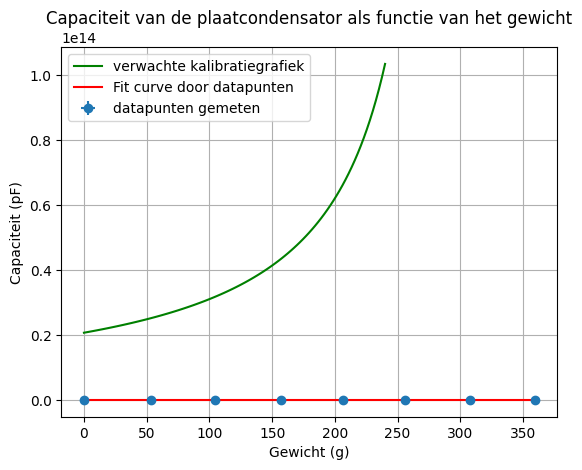

In [7]:
# Plot hier je oorspronkelijke en je uiteindelijke kalibratiegrafieken, fit daar een bijpassende lijn door
# en zet ook de verwachte ontwerpgrafiek erbij

# Door vele struggles met arduino's en andere apparaten hebben we geen tijd gehad om echt een tweede kalibratie te maken. Maar het design is wel erg veel ontwikkeld door het process heen

gewichten_linspace = np.linspace(0, 240, 100) # in gram

afstanden = 1.5 - 0.005 * gewichten_linspace
l = 25
b = 14
epsilonr = 1

capaciteiten = vlakkeplaat(l/100, b/100, afstanden/100, epsilonr) * 1e12 * np.ones_like(gewichten_linspace)  # in pF
plt.figure()
plt.plot(gewichten_linspace, capaciteiten*1e12, 'g-', label='verwachte kalibratiegrafiek')
plt.errorbar(gewichten_meting, capaciteiten_meting, xerr=u_gewichten, yerr=u_capaciteit, fmt='o', label='datapunten gemeten')
plt.plot(xfit, yfit, 'r-', label='Fit curve door datapunten')
plt.xlabel('Gewicht (g)')
plt.ylabel('Capaciteit (pF)')
plt.title('Capaciteit van de plaatcondensator als functie van het gewicht')
plt.grid(); plt.legend()
plt.show()

# Zoals in de grafiek te zien is, kloppen de metingen helemaal niet met de kalibratie grafiek... Dit komt omdat de gemeten epsilonr veel lager is dan de verwachte epsilonr.
# Dit komt waarschijnlijk doordat er lucht tussen de platen zit, en dat de afstand tussen de platen groter is dan verwacht. De metingen zijn dus niet heel betrouwbaar, maar het design is wel erg veel verbeterd door het proces heen.

kopieer hier de cel(len) waaruit blijkt dat jullie leerdoel 3 beheersen.

## Opdracht 7: Plot de kalibratiegrafiek.

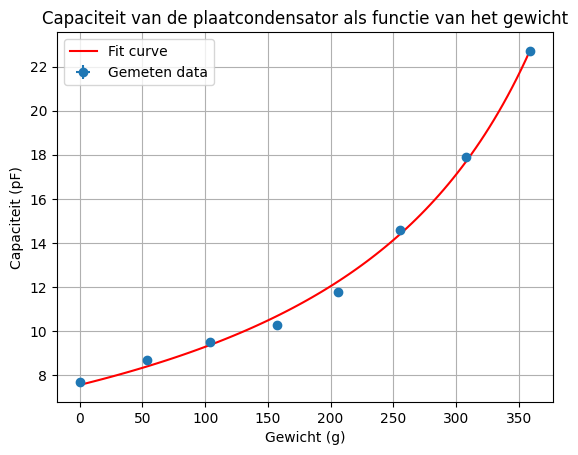

Fit resultaten: epsilonr = 0.0263 ± 0.0007


In [8]:
# Plot hier je gemeten kalibratiegrafiek en plot in dezelfde figuur ook je verwachte ontwerpgrafiek.
def fitfunc(gewicht, eps, gewicht0):
    return epsilon0 * eps * l * b /(8 - 1 * (gewicht + gewicht0)/50) * 1e12

gewichten = np.array([0, 53.5, 104.1, 157.1, 206.1, 255.5, 307.8, 359.2]) # in gram
capaciteiten = np.array([7.7, 8.7, 9.5, 10.3, 11.8, 14.6, 17.9, 22.7]) # in pF

u_gewichten = 0.1
u_capaciteit = 0.1


popt, pcov = curve_fit(fitfunc, gewichten, capaciteiten, p0=[2, 0])

xfit = np.linspace(gewichten.min(), gewichten.max(), 100)
yfit = fitfunc(xfit, *popt)
plt.figure()
plt.errorbar(gewichten, capaciteiten, xerr=u_gewichten, yerr=u_capaciteit, fmt='o', label='Gemeten data')
plt.plot(xfit, yfit, 'r-', label='Fit curve')
plt.xlabel('Gewicht (g)')
plt.ylabel('Capaciteit (pF)')
plt.title('Capaciteit van de plaatcondensator als functie van het gewicht')
plt.grid(); plt.legend()
plt.show()

eps_fit = popt[0]
u_eps_fit = np.sqrt(pcov[0, 0])
print(f"Fit resultaten: epsilonr = {eps_fit:.4f} ± {u_eps_fit:.4f}")

## Opdracht 10: Vul hieronder de conclusie in.

Uiteindelijk is het redelijk gelukt om een werkende gewichtssensor te maken. De sensor kan qua accuraatheid een stuk beter en stabieler gemaakt worden. De onzekerheden van de gemeten waardes zijn echter erg klein, dus dat is goed.

Het verband tussen het gewicht en de capaciteit volgt het verwachte verband goed, maar op een manier met waarden die echt onzin zijn. De epsilonr is bijvoorbeeld is bijvoorbeeld veel te laag, 0.026, terwijl deze voor lucht ongeveer 1 zou moeten zijn. Bovendien is er een corrigeer factor nodig voor het gewicht, die momenteel gefit wordt als -137... Een negatief gewicht voor de opstelling zonder gewichten is natuurlijk onzin. De reden dat deze corrigeer factor nodig is, is waarschijnlijk dat de afstand tussen de platen niet goed bepaald kan worden, en dat er ook nog andere factoren meespelen zoals de veren en de constructie van de sensor.

Een aantal oorzaken voor de slechte waardes is dat we geen mooie platte platen gebruikte, en dat de beginafstand niet goed te meten was. De veren die gebruikt werden waren ook erg stroef, waardoor het gewicht niet altijd de volledige kracht uitoefende op de platen.